# **Parking task**

This implementation is inspired from the book: Robotics, Vision and Control of Peter Corke

I implement the bicycle model to drive the robot to an arbitrary configuration (x, y, theta)

Attention: If the goal is behind the robot i.e. alpha not $\in [-\pi/2, \pi/2]$, you may multiply $v$ ang gamma by (-1),

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [13]:
def normalize(angle):
    return np.arctan2(np.sin(angle), np.cos(angle))


class Controller:
    def __init__(self, k_rho=15, k_alpha=5, k_beta=-2) -> None:
      self.k_rho = k_rho
      self.k_alpha = k_alpha
      self.k_beta = k_beta

    def get_cmds(self, rho, alpha, beta):
      """
        This function applies the control low v = k*rho and w = k*alpha + k*beta
        given angle errors

        input:
        - rho: distance to target pos
         - bearing angle alpha between robot and target pos
         - beta: goal heading in world frame

        output:
        - v: linear speed of the robot
        - omega: angular speed of the unicycle robot
      """
      v = self.k_rho*rho
      omega = self.k_beta*beta + self.k_alpha*alpha

      return v, omega

class Robot:
  def __init__(self, L=1, controller: Controller=Controller(), max_speed=(1.0, 1.0)) -> None:

    self.config = np.array([0, 0, 0])
    self.start_config = self.config.copy()
    self.target_config = np.array([5, 5, np.pi/2])
    self.speed = np.array([0.0, 0.0, 0.0])
    self.L = L # length of the robot car
    self.delta_t = 0.02 # second
    self.controller = controller
    self.distance_to_target = 0
    self.bearing = 0
    self.max_speed = max_speed


  def update_bicycle(self, v, gamma):
    """
      This function implements the bicycle model kinematics.
      Given inputs commands v and gamma, it computes the new
      configuration of the robot from the current configuration
      using the euler integration

      x = x + x_dot*delta_t
      y = y + y_dot*delta_t
      theta = theta + theta_dot*delta_t

      input:
        - speed v
        - steering angle gamma

      action:
        - update configuration at time step t+1
    """
    x_dot = v*np.cos(self.config[2]) # v*cos(theta)
    y_dot = v*np.sin(self.config[2]) # v*sin(theta)
    theta_dot = (v/self.L)*np.tan(gamma) # v*tan(gamma)/

    self.speed[0] = x_dot.copy()
    self.speed[1] = y_dot.copy()
    self.speed[2] = theta_dot.copy()

    self.config[0] = self.config[0] + x_dot*self.delta_t
    self.config[1] = self.config[1] + y_dot*self.delta_t
    self.config[2] = self.config[2] + theta_dot*self.delta_t


    return


  def uni2bicycle(self, v, omega):
    """
      This function transform commands inputs (v, omega) for unicycle robot to
      bicycle robot (v, gamma)

      input:
        - v: linear speed
        - omega: angular speed

      output:
        - v: same linear speed
        - gamma: steering angle of the front wheel
    """
    val = omega*self.L/(v+1e-6)
    gamma = np.atan2(np.sin(val), np.cos(val))

    return v, gamma

  def cartesian2polar(self, delta_x, delta_y):
    """
      This function takes as input delta_x and delta_x and
      compute the polar coordinates rho, alpha, beta for the
      control

      input:
        - delta_x: x coordinate
        - delta_y: y coordinate

      output:
        - alpha: angle of delta_x and delta_y in robot frame
        - rho: norm of the vector (delta_x, delta_y)
        - beta: angle of goal in world frame
    """
    rho = np.linalg.norm(np.array([delta_x, delta_y]))
    alpha = np.atan2(delta_y, delta_x) - self.config[2]

    self.bearing = alpha
    self.distance_to_target = rho

    beta = -(alpha + self.config[2])

    #print(f"alpha_deg: {np.rad2deg(alpha)} beta_deg: {np.rad2deg(beta)}")

    return rho, alpha, beta

  def step(self):
    """
      This function implements one step update of the kinematic model
    """

    # 1. compute difference to goal
    delta_x = self.target_config[0] - self.config[0]
    delta_y = self.target_config[1] - self.config[1]

    # 2. transform to polar coordinate
    polar_config = self.cartesian2polar(delta_x, delta_y)
    rho, alpha, beta = polar_config
    alpha = normalize(alpha)

    # 3. to drive orientation to target configuration
    beta = beta + self.target_config[2]
    beta = normalize(beta)

    # 4. get the unicycle model commands linear and angular speed
    v, omega = self.controller.get_cmds(rho, alpha, beta)
    v = np.clip(v, -self.max_speed[0], self.max_speed[0])
    omega = np.clip(omega, -self.max_speed[1], self.max_speed[1])

    #print(f"config: {v, omega}")
    # 5. transform to bicycle model commands v and gamma
    v, gamma = self.uni2bicycle(v, omega)

    # 6. update robot kinematic using bicycle model
    self.update_bicycle(v, gamma)


class Simulation:
  def __init__(self, init_config:np.ndarray, target_config:np.ndarray, robot:Robot,
               step_dt=0.2, ) -> None:

    self.robot = robot
    self.robot.config = init_config.copy()
    self.robot.start_config = init_config.copy()
    self.robot.target_config = target_config.copy()
    self.robot.delta_t = step_dt
    self.step_dt = step_dt
    self.pos_traj = []
    self.orientation_traj = [init_config[2]]


  def run(self, max_run_time=1.):
    t = 0
    while t <= max_run_time:

      self.robot.step()

      self.pos_traj.append(self.robot.config[:2].copy())
      self.orientation_traj.append(self.robot.config[2].copy())

      t += self.step_dt
      d = np.linalg.norm(self.robot.target_config[:2] - self.robot.config[:2])
      ang = np.abs(self.robot.target_config[2] - self.robot.config[2])
      if d <=0.02 and ang<=0.02:
        print(f"[INFO]start_config: {self.robot.start_config}")
        print(f"[INFO]end_config: {self.robot.config}")
        break

  def plot_traj(self):


    plt.figure()
    x, y = zip(*self.pos_traj)
    plt.plot(x, y, label="pos")
    plt.scatter(self.robot.target_config[0], self.robot.target_config[1], c="r", label="goal")
    plt.scatter(self.robot.start_config[0], self.robot.start_config[1], c="g", label="start")
    plt.scatter(self.robot.config[0], self.robot.config[1], c="b", label="final")

    dx_target, dy_target = np.cos(self.robot.target_config[2]), np.sin(self.robot.target_config[2])
    dx_start, dy_start = np.cos(self.robot.start_config[2]), np.sin(self.robot.start_config[2])
    dx_final, dy_final = np.cos(self.robot.config[2]), np.sin(self.robot.config[2])

    length = 1.5
    width = 0.3

    plt.arrow(x=self.robot.target_config[0], y=self.robot.target_config[1],
              dx=length*dx_target, dy=length*dy_target, color="r", head_width=0.3)
    plt.arrow(x=self.robot.start_config[0], y=self.robot.start_config[1],
              dx=length*dx_start, dy=length*dy_start, color="g", head_width=0.3)
    plt.arrow(x=self.robot.config[0], y=self.robot.config[1],
              dx=0.6*length*dx_final, dy=0.6*length*dy_final, color="b", head_width=0.1)

    plt.legend()
    plt.axis("equal")

    plt.figure()
    plt.plot(self.orientation_traj, label="head")
    plt.hlines(self.robot.target_config[2:], xmin=0, xmax=len(self.orientation_traj), colors=["r"], label="target")
    plt.hlines(self.robot.start_config[2:], xmin=0, xmax=len(self.orientation_traj), colors=["g"], label="start")
    plt.legend()



In [14]:
def test():
  r = Robot()

  config = np.array([0, 0, round(np.pi/2, 3)])
  target_config = np.array([2, 2, 0])

  r.config = config.copy()
  r.target_config = target_config.copy()

  delta_x = r.target_config[0] - r.config[0]
  delta_y = r.target_config[1] - r.config[1]

  print(f"[INFO] config: {r.config} target: {r.target_config} delta_x: {delta_x} delta_y: {delta_x}")

  polar_config = r.cartesian2polar(delta_x, delta_y)
  print(f"[INFO] polar coordinate: {polar_config}")

test()


[INFO] config: [0.    0.    1.571] target: [2 2 0] delta_x: 2.0 delta_y: 2.0
[INFO] polar coordinate: (np.float64(2.8284271247461903), np.float64(-0.7856018366025517), np.float64(-0.7853981633974483))


[INFO]start_config: [0. 0. 0.]
[INFO]end_config: [ 3.98221301 -6.00852586  0.44279006]


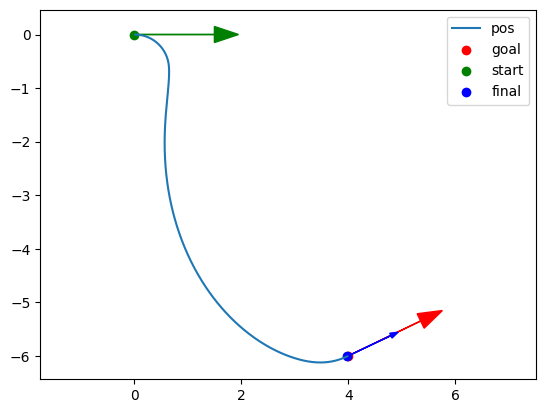

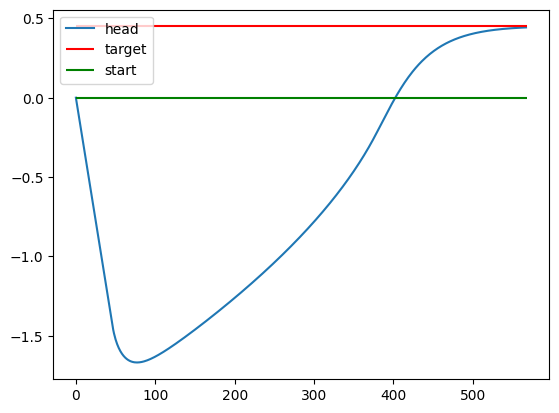

In [15]:
init_config = np.array([0, 0, 0.])
target_config = np.array([4, -6, np.pi/7])
controller = Controller(k_rho=1, k_alpha=3, k_beta=-1.5)
robot = Robot(controller=controller, max_speed=(1.0, 1.))
sim = Simulation(init_config, target_config, robot, step_dt=0.02)
sim.run(100)
sim.plot_traj()